 # 🛠 Instalación de Dependencias / Install Dependencies

Para ejecutar este proyecto, primero instala las dependencias necesarias:

In [1]:
!pip install tensorflow==2.8.0 tensorflow-gpu==2.8.0 opencv-python mediapipe scikit-learn matplotlib

ERROR: Could not find a version that satisfies the requirement tensorflow==2.8.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.19.0rc0)
ERROR: No matching distribution found for tensorflow==2.8.0


# Configuración de MediaPipe Holistic / Set Up MediaPipe Holistic

In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

2025-04-21 15:14:51.913866: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/fabrica/miniconda3/envs/AISol/lib/python3.8/site-packages/cv2/../../lib64:
2025-04-21 15:14:51.913909: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


 ⭕ Este código configura el modelo de MediaPipe Holistic para la detección de poses, manos y rostro.


In [2]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [3]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [4]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [5]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  +
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

# 🎥 Captura de Video y Detección de Puntos Clave / Video Capture and Keypoint Detection

Si deseas hacer una prueba de camara aunque no es necesario activar este  bloque ya que no afecta el flujo del codigo si no llega a activarce, se usa:

Para probar la detección en tiempo real:

In [6]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == 27:
            break
    cap.release()
    cv2.destroyAllWindows()

I0000 00:00:1745266514.936556   18248 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1745266514.975955   19749 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.230.02), renderer: NVIDIA T600/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

⭕ Si la cámara no se activa, verifica que esté bien conectada y probada con cv2.VideoCapture(0).

In [7]:
draw_landmarks(frame, results)

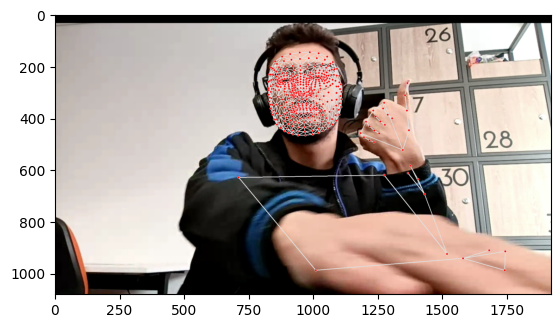

In [8]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

⭕‼️ en los siguientes cuatro bloques lo cuales no son necesarios activarlos , solo si quieres observar los puntos extraidos en la prueba anterios de camara en tiempo real , si la prueba de camara no fue realizada ,los siguientes bloques dara errores pero no afectaran el flujo del codigo.

pero lo recomendable es que no sean activados si la pruba de arriva de la camara no fu realizada.

In [9]:
len(results.left_hand_landmarks.landmark) 

21

In [10]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [11]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [12]:
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
#lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)


✅ este bloque es el unico que debe ser activado porque si afecta el flujo del codigo ya que de esta funcion se extraen los puntos que se configuran en las primeras funciones de Mediapipe configuradas entre los primeros pasos.

In [13]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [14]:
result_test = extract_keypoints(results)

In [15]:
result_test

array([ 0.50170845,  0.28417981, -0.14079648, ...,  0.        ,
        0.        ,  0.        ])

In [16]:
np.save('0', result_test)

In [17]:
np.load('0.npy')

array([ 0.50170845,  0.28417981, -0.14079648, ...,  0.        ,
        0.        ,  0.        ])

# Creación de Carpetas para Datos / Create Data Folders

Si necesitas recolectar datos para entrenamiento, asegúrate de que las carpetas existen:

In [107]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('Dataset')

# Actions that we try to detect
actions = np.array(['el', 'tu', 'yo'])
########### Este listas de ALS, cambiar LSC #########

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 20

Este paso solo es necesario si vas a recopilar datos nuevamente. Si ya tienes datos, puedes omitirlo.

In [108]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

# Guardar - primero video como clave puntos        

# Creacion de videos y de la data  / creating data and videos

Si ya tienes los datos procesados, puedes entrenar el modelo sin necesidad de recolectar nuevos datos:

In [20]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):#start_folder, start_folder+no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

I0000 00:00:1745266715.410911   18248 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1745266715.445223   20259 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.230.02), renderer: NVIDIA T600/PCIe/SSE2


In [86]:
cap.release()
cv2.destroyAllWindows()

# Preprocesar datos y crear etiquetas y funciones / Preprocess Data and Create Labels and Features

In [87]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [88]:
label_map = {label:num for num, label in enumerate(actions)}

In [89]:
label_map

{'Amor': 0, 'Gracias': 1, 'Hola': 2}

In [90]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

FileNotFoundError: [Errno 2] No such file or directory: 'Basicos/Amor/26/0.npy'

In [26]:
np.array(sequences).shape

(90, 20, 1662)

In [27]:
np.array(labels).shape

(90,)

In [28]:
X = np.array(sequences)

In [29]:
X.shape

(90, 20, 1662)

In [30]:
y = to_categorical(labels).astype(int)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [32]:
y_test.shape

(5, 3)

# Entrenamiento del Modelo / Train the Model

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D, LSTM, Dense, Flatten
from tensorflow.keras.callbacks import TensorBoard

In [34]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

En el bloque de abajo esta los parametros de laca acpas para el modelo 1 

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [109]:
# Modelo 1
# Nuevo modelo convolucional
model = Sequential()

# Capas convolucionales para extracción de características
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(20, 1662)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Capa LSTM para modelado temporal
model.add(LSTM(128, return_sequences=False)) # return_sequences=False porque solo necesitamos la salida final de la secuencia

# Capas densas para clasificación
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(actions.shape[0], activation='softmax'))

In [37]:
# Modelo 2
# Crear el modelo secuencial
model = Sequential()

# Añadir una capa convolucional
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(20, 1662)))

# Añadir una capa de pooling
model.add(MaxPooling1D(pool_size=2))

# Añadir una segunda capa convolucional
model.add(Conv1D(128, kernel_size=3, activation='relu'))

# Añadir una segunda capa de pooling
model.add(MaxPooling1D(pool_size=2))

# Añadir una tercera capa convolucional
model.add(Conv1D(128, kernel_size=3, activation='relu'))

# Utilizar GlobalMaxPooling1D en lugar de MaxPooling1D para evitar problemas de tamaño
model.add(GlobalMaxPooling1D())

# Aplanar la salida antes de las capas densas
model.add(Flatten())

# Añadir una capa densa
model.add(Dense(64, activation='relu'))

# Añadir una segunda capa densa
model.add(Dense(64, activation='relu'))

# Añadir una tercera capa densa
model.add(Dense(32, activation='relu'))

# Añadir una cuarta capa densa
model.add(Dense(32, activation='relu'))

# Añadir la capa de salida
model.add(Dense(actions.shape[0], activation='softmax'))

2025-04-10 12:49:33.604292: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/fabrica/miniconda3/envs/AISol/lib/python3.8/site-packages/cv2/../../lib64:
2025-04-10 12:49:33.604356: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/fabrica/miniconda3/envs/AISol/lib/python3.8/site-packages/cv2/../../lib64:
2025-04-10 12:49:33.604395: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/fabrica/miniconda3/envs/AISol/lib/python3.8/site-packages/cv2/../../lib64:
2025-04-10 12:49:

In [110]:
# Modelo 1
# Compilación del modelo
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [38]:
# Modelo 2
# Compilar el modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [111]:
model.fit(X_train, y_train, epochs=2000, callbacks=[tb_callback])

Epoch 1/2000
3/3 [==============================] - 2s 10ms/step - loss: 1.7130 - accuracy: 0.2706
Epoch 2/2000
3/3 [==============================] - 0s 9ms/step - loss: 0.9538 - accuracy: 0.5882
Epoch 3/2000
3/3 [==============================] - 0s 10ms/step - loss: 0.9429 - accuracy: 0.6706
Epoch 4/2000
3/3 [==============================] - 0s 9ms/step - loss: 0.5820 - accuracy: 0.7176
Epoch 5/2000
3/3 [==============================] - 0s 10ms/step - loss: 0.3631 - accuracy: 0.8353
Epoch 6/2000
3/3 [==============================] - 0s 9ms/step - loss: 0.3772 - accuracy: 0.8471
Epoch 7/2000
3/3 [==============================] - 0s 9ms/step - loss: 0.2887 - accuracy: 0.9059
Epoch 8/2000
3/3 [==============================] - 0s 9ms/step - loss: 0.2723 - accuracy: 0.8824
Epoch 9/2000
3/3 [==============================] - 0s 9ms/step - loss: 0.1894 - accuracy: 0.9294
Epoch 10/2000
3/3 [==============================] - 0s 9ms/step - loss: 0.2173 - accuracy: 0.9412
Epoch 11/2000
3/

In [112]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_4 (Conv1D)           (None, 18, 64)            319168    
                                                                 
 batch_normalization_6 (Batc  (None, 18, 64)           256       
 hNormalization)                                                 
                                                                 
 max_pooling1d_4 (MaxPooling  (None, 9, 64)            0         
 1D)                                                             
                                                                 
 conv1d_5 (Conv1D)           (None, 7, 128)            24704     
                                                                 
 batch_normalization_7 (Batc  (None, 7, 128)           512       
 hNormalization)                                                 
                                                      

# 8. Make Predictions

In [113]:
res = model.predict(X_test)

In [114]:
actions[np.argmax(res[1])]

'el'

In [115]:
actions[np.argmax(y_test[1])]

'el'

# 9. Save Weights

In [116]:
model.save('prueba2000.h5')

In [ ]:
#del model

In [117]:
model.load_weights('prueba2000.h5')

# 10. Evaluation using Confusion Matrix and Accuracy

In [118]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [119]:
yhat = model.predict(X_test)

In [120]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [121]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[3, 0],
        [0, 2]],

       [[2, 2],
        [0, 1]],

       [[3, 0],
        [2, 0]]])

In [122]:
accuracy_score(ytrue, yhat)

0.6

# 11. Test in Real Time

In [123]:
from scipy import stats

In [124]:
colors = [(245,117,16), (117,245,16), (16,117,245),(163,117,245),(17,117,245)]
def prob_viz (res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [125]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

TypeError: only size-1 arrays can be converted to Python scalars

<Figure size 1800x1800 with 0 Axes>

In [126]:
# 1. New detection variables
sequence = []
sentence = []
threshold = 0.8
hand_detected = False  # Variable para rastrear si se detectan manos

cap = cv2.VideoCapture(0)
# Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)

        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Verificar si se detectan manos
        if results.left_hand_landmarks or results.right_hand_landmarks:
            hand_detected = True
        else:
            hand_detected = False
            sequence = []  # Reiniciar la secuencia si no hay manos
            sentence = []  # Reiniciar la sentencia si no hay manos

        # 2. Prediction logic (solo si se detectan manos)
        if hand_detected:
            keypoints = extract_keypoints(results)
            sequence.append(keypoints)
            sequence = sequence[-20:]

            if len(sequence) == 20:
                res = model.predict(np.expand_dims(sequence, axis=0))[0]
                print(actions[np.argmax(res)])

                # 3. Viz logic
                if res[np.argmax(res)] > threshold:
                    if len(sentence) > 0:
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

                if len(sentence) > 5:
                    sentence = sentence[-5:]

                # Viz probabilities
                image = prob_viz(res, actions, image, colors)

        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

        # Mostrar el estado de detección de manos
        if hand_detected:
            cv2.putText(image, 'Manos Detectadas', (450, 380), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
        else:
            cv2.putText(image, 'Esperando Manos', (450, 380), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2, cv2.LINE_AA)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == 27:
            break
    cap.release()
    cv2.destroyAllWindows()

I0000 00:00:1745271681.125346   18248 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1745271681.215900   96099 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.230.02), renderer: NVIDIA T600/PCIe/SSE2


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti